### Selected features with ANOVA 

### 1. Imports and Setup

In [ ]:
# Cell 1: Imports and setup
import pandas as pd
from tsfresh import extract_features
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters
import numpy as np
from scipy import stats
from scipy.stats import f_oneway
from tslearn.clusteri2ng import TimeSeriesKMeans
from tslearn.metrics import dtw, dtw_path
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For better display in Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('✅ All libraries imported successfully!')

c:\Users\Teresa\anaconda3\Lib\site-packages\tsfresh\__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Teresa\anaconda3\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


✅ All libraries imported successfully!


### 2. Data Loading and Preparation

In [2]:
# Cell 2: Load and prepare data
csv_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\tsfresh_features_SPSS.csv"

# Load the data
print("📂 Loading TSFresh features...")
df = pd.read_csv(csv_path, index_col=0)
print(f"✅ Data loaded: {df.shape}")

# Check group column
if 'group' in df.columns:
    groups = df['group']
    group_info = df[['group']].copy()
    print(f"👥 Groups: {groups.value_counts().to_dict()}")
else:
    print("❌ Group column not found!")

# Get numeric features only
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = df[numeric_cols].copy()

print(f"📊 Data overview:")
print(f"   • Total columns: {df.shape[1]}")
print(f"   • Non-numeric columns: {len(non_numeric_cols)} - {non_numeric_cols}")
print(f"   • Numeric features: {len(numeric_cols)}")
print(f"   • Samples: {df.shape[0]}")

# Show first few rows
print(f"\n📋 First 3 rows of features:")
display(features.head(3))

📂 Loading TSFresh features...
✅ Data loaded: (107, 1570)
👥 Groups: {'Control': 70, 'Study': 37}
📊 Data overview:
   • Total columns: 1570
   • Non-numeric columns: 1 - ['group']
   • Numeric features: 1569
   • Samples: 107

📋 First 3 rows of features:


volume_ml  detected_swallows  expected_swallows  \
audio_file                                                         
GC-F10-10ml.wav         10                  2                  2   
GC-F10-20ml.wav         20                  2                  2   
GC-F10-3ml.wav           3                  1                  1   

                 spl_db__abs_energy_pre_swallow  \
audio_file                                        
GC-F10-10ml.wav                   112518.788286   
GC-F10-20ml.wav                   143200.739776   
GC-F10-3ml.wav                    156887.346914   

                 spl_db__absolute_maximum_pre_swallow  \
audio_file                                              
GC-F10-10ml.wav                             83.230873   
GC-F10-20ml.wav                             95.660832   
GC-F10-3ml.wav                              99.243326   

                 spl_db__absolute_sum_of_changes_pre_swallow  \
audio_file                                                     
GC-F10-10ml.wav                                   287.953433   
GC-F10-20ml.wav                                   312.932123   
GC-F10-3ml.wav                                    305.790041   

                 spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_40_pre_swallow  \
audio_file                                                                          
GC-F10-10ml.wav                                           0.591706                  
GC-F10-20ml.wav                                           0.492646                  
GC-F10-3ml.wav                                            0.575539                  

                 spl_db__agg_autocorrelation__f_agg_"median"__maxlag_40_pre_swallow  \
audio_file                                                                            
GC-F10-10ml.wav                                           0.593840                    
GC-F10-20ml.wav                                           0.486761                    
GC-F10-3ml.wav                                            0.596064                    

                 spl_db__agg_autocorrelation__f_agg_"var"__maxlag_40_pre_swallow  \
audio_file                                                                         
GC-F10-10ml.wav                                           0.031220                 
GC-F10-20ml.wav                                           0.042903                 
GC-F10-3ml.wav                                            0.031157                 

                 spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"max"_pre_swallow  \
audio_file                                                                                           
GC-F10-10ml.wav                                          26.342540                                   
GC-F10-20ml.wav                                          13.637728                                   
GC-F10-3ml.wav                                           17.519691                                   

                 spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"mean"_pre_swallow  \
audio_file                                                                                            
GC-F10-10ml.wav                                          23.012362                                    
GC-F10-20ml.wav                                          10.343108                                    
GC-F10-3ml.wav                                           13.940927                                    

                 spl_db__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"min"_pre_swallow  \
audio_file                                                                                           
GC-F10-10ml.wav                                          19.320550                                   
GC-F10-20ml.wav                                           7.538747                                   
GC-F10-3ml.wav                                           12.092320                             

### 3. ANOVA Feature Selection

In [3]:
# Cell 3: ANOVA Feature Selection Function
def anova_feature_selection(csv_path, group_column='group', p_threshold=0.05, eta_squared_threshold=0.06):
    """
    ANOVA-based feature selection for continuous variables
    Better alternative to chi-square for continuous data
    """
    print("🎯 ANOVA FEATURE SELECTION FOR CONTINUOUS DATA")
    print("=" * 50)
    
    # Load data
    df = pd.read_csv(csv_path, index_col=0)
    print(f"📂 Loaded data: {df.shape}")
    
    # Get group information
    if group_column in df.columns:
        groups = df[group_column]
        features_df = df.drop(columns=[group_column])
        unique_groups = groups.unique()
        print(f"👥 Groups: {groups.value_counts().to_dict()}")
    else:
        print(f"❌ Group column '{group_column}' not found!")
        return None, None
    
    # Get numeric features
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
    features = features_df[numeric_cols].copy()
    
    print(f"📊 Testing {len(numeric_cols)} continuous features")
    
    # ANOVA feature selection
    selected_features = []
    results = []
    
    print("🧪 Running ANOVA tests...")
    
    for i, feature in enumerate(features.columns):
        try:
            # Get feature values for each group
            group_data = []
            for group in unique_groups:
                group_indices = groups == group
                group_values = features.loc[group_indices, feature].dropna()
                group_data.append(group_values)
            
            # Skip if any group has insufficient data
            if any(len(data) < 3 for data in group_data):
                continue
            
            # One-way ANOVA
            f_stat, p_val = f_oneway(*group_data)
            
            # Calculate eta-squared (effect size for ANOVA)
            all_values = features[feature].dropna()
            grand_mean = all_values.mean()
            
            # Between-group sum of squares
            ss_between = sum(len(data) * (data.mean() - grand_mean)**2 for data in group_data)
            
            # Total sum of squares
            ss_total = sum((val - grand_mean)**2 for val in all_values)
            
            eta_squared = ss_between / ss_total if ss_total > 0 else 0
            
            # Selection criteria
            significant = p_val < p_threshold
            large_effect = eta_squared > eta_squared_threshold
            selected = significant and large_effect
            
            # Group means for interpretation
            group_means = {group: data.mean() for group, data in zip(unique_groups, group_data)}
            group_stds = {group: data.std() for group, data in zip(unique_groups, group_data)}
            
            results.append({
                'feature': feature,
                'f_statistic': f_stat,
                'p_value': p_val,
                'eta_squared': eta_squared,
                'effect_size_interpretation': 'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small',
                **{f'mean_{group}': group_means[group] for group in unique_groups},
                **{f'std_{group}': group_stds[group] for group in unique_groups},
                'selected': selected
            })
            
            if selected:
                selected_features.append(feature)
            
            # Show progress
            if i < 10:
                print(f"   {i+1:3d}. {feature[:50]:<50} | F={f_stat:6.2f}, p={p_val:.3e}, η²={eta_squared:.3f}, selected={selected}")
                
        except Exception as e:
            if i < 5:
                print(f"   ❌ Error with {feature}: {e}")
            continue
    
    # Results summary
    results_df = pd.DataFrame(results)
    n_selected = len(selected_features)
    
    print(f"\n📊 ANOVA SELECTION RESULTS:")
    print(f"   🔸 Features tested: {len(results)}")
    print(f"   ✅ Significant differences: {n_selected}")
    print(f"   📉 Feature reduction: {(1 - n_selected/len(features.columns))*100:.1f}%")
    
    if n_selected == 0:
        print("⚠️ No significant group differences found!")
        print(f"💡 Try lowering thresholds: p_threshold={p_threshold} or eta_squared_threshold={eta_squared_threshold}")
        return None, results_df
    
    # Show top features
    print(f"\n🏆 TOP FEATURES WITH GROUP DIFFERENCES:")
    print("-" * 80)
    
    selected_results = results_df[results_df['selected']].copy()
    selected_results = selected_results.sort_values('eta_squared', ascending=False)
    
    for i, (_, result) in enumerate(selected_results.head(15).iterrows(), 1):
        print(f"{i:2d}. {result['feature'][:50]}")
        print(f"     η² = {result['eta_squared']:6.3f} ({result['effect_size_interpretation']} effect)")
        print(f"     F = {result['f_statistic']:6.2f}, p = {result['p_value']:.2e}")
        
        # Show group differences
        group_info = " | ".join([f"{group}: {result[f'mean_{group}']:.2f}±{result[f'std_{group}']:.2f}" 
                                for group in unique_groups])
        print(f"     Groups: {group_info}")
        print()
    
    final_features = features[selected_features]
    
    print(f"\n✅ ANOVA FEATURE SELECTION COMPLETE!")
    print(f"   📊 Selected features shape: {final_features.shape}")
    
    return final_features, results_df

print("✅ ANOVA feature selection function defined!")

✅ ANOVA feature selection function defined!


In [4]:
# Cell 4: Run ANOVA Feature Selection
print("🚀 RUNNING ANOVA FEATURE SELECTION")
print("=" * 50)

# Run ANOVA feature selection
selected_features_anova, results_anova = anova_feature_selection(
    csv_path=csv_path,
    group_column='group',
    p_threshold=0.05,
    eta_squared_threshold=0.06  # Medium effect size threshold
)

# Verify the results
print(f"\n🎯 VERIFICATION:")
print(f"   📊 selected_features_anova shape: {selected_features_anova.shape}")
print(f"   📋 results_anova shape: {results_anova.shape}")
print(f"   ✅ Variables successfully created!")

🚀 RUNNING ANOVA FEATURE SELECTION
🎯 ANOVA FEATURE SELECTION FOR CONTINUOUS DATA
📂 Loaded data: (107, 1570)
👥 Groups: {'Control': 70, 'Study': 37}
📊 Testing 1569 continuous features
🧪 Running ANOVA tests...
     1. volume_ml                                          | F=  2.75, p=1.002e-01, η²=0.026, selected=False
     2. detected_swallows                                  | F=  4.34, p=3.961e-02, η²=0.040, selected=False
     3. expected_swallows                                  | F=  4.35, p=3.942e-02, η²=0.040, selected=False
     4. spl_db__abs_energy_pre_swallow                     | F=  7.64, p=6.756e-03, η²=0.068, selected=True
     5. spl_db__absolute_maximum_pre_swallow               | F=  0.19, p=6.639e-01, η²=0.002, selected=False
     6. spl_db__absolute_sum_of_changes_pre_swallow        | F=  4.15, p=4.418e-02, η²=0.038, selected=False
     7. spl_db__agg_autocorrelation__f_agg_"mean"__maxlag_ | F=  0.60, p=4.385e-01, η²=0.006, selected=False
     8. spl_db__agg_autocorrelat

### 4. DTW Analysis Setup

In [7]:
# Cell 5: FIXED DTW Functions for ANOVA Features
def prepare_data_for_dtw_anova_fixed(selected_features, group_info=None):
    """
    Fixed DTW preparation for ANOVA-selected features
    Handles unmatched pre/post feature counts
    """
    print("🔧 PREPARING ANOVA FEATURES FOR DTW ANALYSIS (FIXED)")
    print("=" * 55)
    
    # Separate pre and post swallow features
    pre_cols = [col for col in selected_features.columns if any(p in col for p in ['pre_swallow', '__pre', '_pre'])]
    post_cols = [col for col in selected_features.columns if any(p in col for p in ['post_swallow', '__post', '_post'])]
    other_cols = [col for col in selected_features.columns if col not in pre_cols and col not in post_cols]
    
    print(f"📊 Feature breakdown:")
    print(f"   • Total ANOVA features: {selected_features.shape[1]}")
    print(f"   • Pre-swallow features: {len(pre_cols)}")
    print(f"   • Post-swallow features: {len(post_cols)}")
    print(f"   • Other features: {len(other_cols)}")
    print(f"   • Samples: {selected_features.shape[0]}")
    
    # METHOD 1: Find matched pre/post pairs
    print(f"\n🔍 Finding matched pre/post feature pairs...")
    
    matched_pairs = []
    for pre_col in pre_cols:
        # Try to find corresponding post feature
        base_name = pre_col
        for old_pattern in ['_pre_swallow', '__pre', '_pre']:
            if old_pattern in pre_col:
                base_name = pre_col.replace(old_pattern, '')
                break
        
        # Look for post version
        for post_pattern in ['_post_swallow', '__post', '_post']:
            potential_post = base_name + post_pattern
            if potential_post in post_cols:
                matched_pairs.append({
                    'base': base_name,
                    'pre': pre_col,
                    'post': potential_post
                })
                break
    
    print(f"   ✅ Found {len(matched_pairs)} matched pre/post pairs")
    
    if len(matched_pairs) < 10:
        print(f"   ⚠️ Few matched pairs, using all features as single time-point")
        return prepare_all_features_dtw(selected_features, group_info)
    
    # Use matched pairs for time series
    print(f"\n🎯 Creating time series from {len(matched_pairs)} matched pairs...")
    
    time_series_data = []
    sample_names = []
    used_pre_cols = [pair['pre'] for pair in matched_pairs]
    used_post_cols = [pair['post'] for pair in matched_pairs]
    
    for idx in selected_features.index:
        pre_values = selected_features.loc[idx, used_pre_cols].values
        post_values = selected_features.loc[idx, used_post_cols].values
        
        # Create time series: [pre_features] → [post_features]
        time_series = np.column_stack([pre_values, post_values])
        time_series_data.append(time_series)
        sample_names.append(idx)
    
    # Convert to tslearn format
    ts_dataset = to_time_series_dataset(time_series_data)
    
    print(f"📊 Time series dataset created:")
    print(f"   • Shape: {ts_dataset.shape}")
    print(f"   • Matched feature pairs: {len(matched_pairs)}")
    
    return ts_dataset, sample_names, used_pre_cols, used_post_cols

def prepare_all_features_dtw(selected_features, group_info=None):
    """
    Alternative: Use all ANOVA features for clustering (no time series)
    """
    print("🔄 USING ALL ANOVA FEATURES FOR CLUSTERING")
    print("=" * 45)
    
    print(f"📊 Converting to pseudo-time-series:")
    print(f"   • All features: {selected_features.shape[1]}")
    print(f"   • Samples: {selected_features.shape[0]}")
    
    time_series_data = []
    sample_names = []
    
    for idx in selected_features.index:
        # Use all features as a single time-point
        feature_vector = selected_features.loc[idx].values
        time_series = feature_vector.reshape(-1, 1)  # Shape: (n_features, 1)
        
        time_series_data.append(time_series)
        sample_names.append(idx)
    
    # Convert to tslearn format
    ts_dataset = to_time_series_dataset(time_series_data)
    
    print(f"✅ Dataset ready for DTW clustering:")
    print(f"   • Shape: {ts_dataset.shape}")
    
    return ts_dataset, sample_names, selected_features.columns.tolist(), []

# Keep original DTW clustering function (no changes needed)
def calculate_dtw_silhouette(ts_data, labels, sample_size=50):
    # ... (same as before)
    if len(ts_data) > sample_size:
        indices = np.random.choice(len(ts_data), sample_size, replace=False)
        ts_sample = ts_data[indices]
        labels_sample = labels[indices]
    else:
        ts_sample = ts_data
        labels_sample = labels
    
    n_samples = len(ts_sample)
    distances = np.zeros((n_samples, n_samples))
    
    print(f"   🔄 Computing DTW distances for {n_samples} samples...")
    
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = dtw(ts_sample[i], ts_sample[j])
            distances[i, j] = distances[j, i] = dist
    
    silhouette_vals = []
    for i in range(n_samples):
        same_cluster = distances[i][labels_sample == labels_sample[i]]
        a = np.mean(same_cluster[same_cluster > 0])
        
        b = float('inf')
        for other_label in np.unique(labels_sample):
            if other_label != labels_sample[i]:
                other_cluster = distances[i][labels_sample == other_label]
                if len(other_cluster) > 0:
                    b = min(b, np.mean(other_cluster))
        
        if b == float('inf'):
            silhouette_vals.append(0)
        else:
            silhouette_vals.append((b - a) / max(a, b))
    
    return np.mean(silhouette_vals)

def dtw_clustering_analysis(ts_dataset, sample_names, group_info=None, n_clusters_range=[2,3,4,5,6]):
    # ... (same as before - no changes needed)
    print(f"🎯 DTW-BASED CLUSTERING ANALYSIS")
    print("=" * 40)
    
    scaler = TimeSeriesScalerMeanVariance()
    ts_scaled = scaler.fit_transform(ts_dataset)
    
    print(f"🧪 Testing cluster numbers: {n_clusters_range}")
    
    results = {}
    silhouette_scores = []
    inertias = []
    
    for n_clusters in n_clusters_range:
        print(f"\n🔄 Testing {n_clusters} clusters...")
        
        km = TimeSeriesKMeans(
            n_clusters=n_clusters,
            metric="dtw",
            random_state=42,
            verbose=False,
            max_iter=10,
            n_init=3
        )
        
        cluster_labels = km.fit_predict(ts_scaled)
        
        try:
            sil_score = calculate_dtw_silhouette(ts_scaled, cluster_labels)
            silhouette_scores.append(sil_score)
        except Exception as e:
            print(f"   ⚠️ Silhouette calculation failed: {e}")
            silhouette_scores.append(0)
        
        inertias.append(km.inertia_)
        
        results[n_clusters] = {
            'model': km,
            'labels': cluster_labels,
            'silhouette': silhouette_scores[-1],
            'inertia': km.inertia_
        }
        
        print(f"   ✅ Silhouette score: {silhouette_scores[-1]:.3f}")
        unique, counts = np.unique(cluster_labels, return_counts=True)
        print(f"   🏷️ Cluster distribution: {dict(zip(unique, counts))}")
    
    best_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
    best_model = results[best_n_clusters]['model']
    best_labels = results[best_n_clusters]['labels']
    
    print(f"\n🏆 OPTIMAL CLUSTERING RESULTS:")
    print(f"   🎯 Best number of clusters: {best_n_clusters}")
    print(f"   📈 Best silhouette score: {max(silhouette_scores):.3f}")
    
    return results, best_model, best_labels, best_n_clusters, silhouette_scores, inertias

print("✅ Fixed DTW functions defined!")

✅ Fixed DTW functions defined!


In [8]:
# Cell 6: Run FIXED DTW Analysis with ANOVA Features
print("🚀 RUNNING FIXED DTW ANALYSIS WITH ANOVA-SELECTED FEATURES")
print("=" * 60)

# Use the FIXED preparation function
ts_dataset, sample_names, pre_cols, post_cols = prepare_data_for_dtw_anova_fixed(selected_features_anova, group_info)

# Run DTW clustering (unchanged)
results, best_model, best_labels, best_n_clusters, silhouette_scores, inertias = dtw_clustering_analysis(
    ts_dataset, sample_names, group_info, n_clusters_range=[2,3,4,5,6]
)

print(f"\n🎉 FIXED DTW CLUSTERING COMPLETE!")
print(f"   📊 Optimal clusters: {best_n_clusters}")
print(f"   🎯 Cluster assignments available in 'best_labels'")
print(f"   📋 Time series data in 'ts_dataset'")

🚀 RUNNING FIXED DTW ANALYSIS WITH ANOVA-SELECTED FEATURES
🔧 PREPARING ANOVA FEATURES FOR DTW ANALYSIS (FIXED)
📊 Feature breakdown:
   • Total ANOVA features: 102
   • Pre-swallow features: 63
   • Post-swallow features: 39
   • Other features: 0
   • Samples: 107

🔍 Finding matched pre/post feature pairs...
   ✅ Found 17 matched pre/post pairs

🎯 Creating time series from 17 matched pairs...
📊 Time series dataset created:
   • Shape: (107, 17, 2)
   • Matched feature pairs: 17
🎯 DTW-BASED CLUSTERING ANALYSIS
🧪 Testing cluster numbers: [2, 3, 4, 5, 6]

🔄 Testing 2 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.473
   🏷️ Cluster distribution: {0: 32, 1: 75}

🔄 Testing 3 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.413
   🏷️ Cluster distribution: {0: 17, 1: 39, 2: 51}

🔄 Testing 4 clusters...
   🔄 Computing DTW distances for 50 samples...
   ✅ Silhouette score: 0.387
   🏷️ Cluster distribution: {0: 3, 1: 43, 2: 36

### 5. Visualization and Analysis

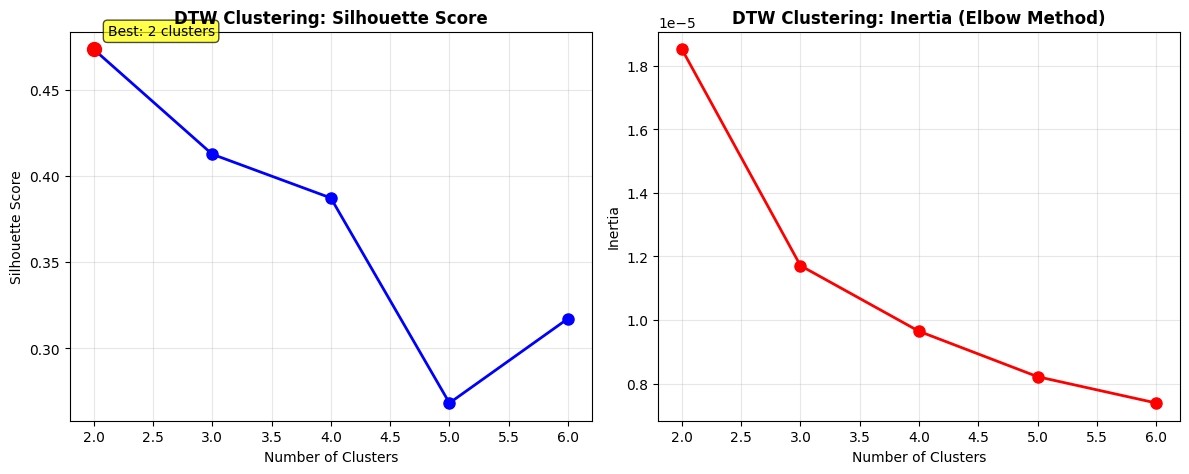

In [9]:
# Cell 7: Plot Clustering Performance
def plot_clustering_performance(silhouette_scores, inertias, n_clusters_range):
    """
    Plot clustering performance metrics
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Silhouette scores
    ax1.plot(n_clusters_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('DTW Clustering: Silhouette Score', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Highlight best score
    best_idx = np.argmax(silhouette_scores)
    ax1.scatter(n_clusters_range[best_idx], silhouette_scores[best_idx], 
               color='red', s=100, zorder=5)
    ax1.annotate(f'Best: {n_clusters_range[best_idx]} clusters', 
                xy=(n_clusters_range[best_idx], silhouette_scores[best_idx]),
                xytext=(10, 10), textcoords='offset points', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Inertias (Elbow method)
    ax2.plot(n_clusters_range, inertias, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters')
    ax2.set_ylabel('Inertia')
    ax2.set_title('DTW Clustering: Inertia (Elbow Method)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot performance metrics
n_clusters_range = [2,3,4,5,6]
plot_clustering_performance(silhouette_scores, inertias, n_clusters_range)

In [10]:
# Cell 8: Group vs Cluster Analysis
def analyze_group_cluster_distribution(cluster_labels, group_info):
    """
    Analyze if Control vs Study groups have different cluster distributions
    """
    from scipy.stats import chi2_contingency
    
    groups = group_info.iloc[:, 0].values
    
    # Create contingency table
    contingency = pd.crosstab(groups, cluster_labels, margins=True)
    print("📊 GROUP vs CLUSTER DISTRIBUTION:")
    print(contingency)
    
    # Statistical test
    chi2, p_val, dof, expected = chi2_contingency(contingency.iloc[:-1, :-1])
    
    print(f"\n🧪 Chi-square test:")
    print(f"   χ² = {chi2:.3f}, p = {p_val:.3f}")
    
    if p_val < 0.05:
        print("   ✅ Significant difference in cluster distribution between groups")
    else:
        print("   ❌ No significant difference in cluster distribution")
    
    return contingency

# Run group analysis
contingency_table = analyze_group_cluster_distribution(best_labels, group_info)

📊 GROUP vs CLUSTER DISTRIBUTION:
col_0     0   1  All
row_0               
Control  18  52   70
Study    14  23   37
All      32  75  107

🧪 Chi-square test:
   χ² = 1.168, p = 0.280
   ❌ No significant difference in cluster distribution


### 6. Results Summary

In [11]:
# Cell 9: Final Results Summary
print("🎯 COMPLETE ANALYSIS SUMMARY")
print("=" * 50)

print(f"📊 ANOVA Feature Selection:")
print(f"   • Original features: {len(features.columns)}")
print(f"   • Selected features: {selected_features_anova.shape[1]}")
print(f"   • Reduction: {(1 - selected_features_anova.shape[1]/len(features.columns))*100:.1f}%")

print(f"\n🎭 DTW Clustering Results:")
print(f"   • Optimal clusters: {best_n_clusters}")
print(f"   • Best silhouette score: {max(silhouette_scores):.3f}")
print(f"   • Samples: {len(sample_names)}")

# Show cluster sizes
unique_labels, counts = np.unique(best_labels, return_counts=True)
print(f"\n🏷️ Cluster Distribution:")
for label, count in zip(unique_labels, counts):
    percentage = (count / len(best_labels)) * 100
    print(f"   • Cluster {label}: {count} samples ({percentage:.1f}%)")

print(f"\n✅ All variables successfully created:")
print(f"   📊 selected_features_anova: {selected_features_anova.shape}")
print(f"   📋 results_anova: {results_anova.shape}")
print(f"   🎭 best_labels: {len(best_labels)} cluster assignments")
print(f"   📈 ts_dataset: {ts_dataset.shape}")
print(f"   👥 group_info: {group_info.shape}")

print(f"\n🎉 ANALYSIS COMPLETE! Ready for further investigation.")

🎯 COMPLETE ANALYSIS SUMMARY
📊 ANOVA Feature Selection:
   • Original features: 1569
   • Selected features: 102
   • Reduction: 93.5%

🎭 DTW Clustering Results:
   • Optimal clusters: 2
   • Best silhouette score: 0.473
   • Samples: 107

🏷️ Cluster Distribution:
   • Cluster 0: 32 samples (29.9%)
   • Cluster 1: 75 samples (70.1%)

✅ All variables successfully created:
   📊 selected_features_anova: (107, 102)
   📋 results_anova: (1569, 10)
   🎭 best_labels: 107 cluster assignments
   📈 ts_dataset: (107, 17, 2)
   👥 group_info: (107, 1)

🎉 ANALYSIS COMPLETE! Ready for further investigation.
